In [1]:
import warnings
warnings.filterwarnings('ignore') 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np, pickle, time
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTENC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import warnings
warnings.simplefilter('ignore')

In [2]:
kag_train = pd.read_csv('KaggleV2-May-2016.csv', low_memory=False)

In [3]:
kag_train.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
print(kag_train.shape)

(110527, 14)


In [5]:
kag_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
kag_train.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [7]:
kag_train.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [8]:
# Convert to datetime FIRST
kag_train['AppointmentDay'] = pd.to_datetime(kag_train['AppointmentDay'])

# Appointment weekday
kag_train['AppointmentWeekday'] = kag_train['AppointmentDay'].dt.day_name()

# Weekend flag
kag_train['IsWeekend'] = kag_train['AppointmentDay'].dt.weekday >= 5
kag_train['IsWeekend'] = kag_train['IsWeekend'].map({True: 'Yes', False: 'No'})

In [9]:
date = ['ScheduledDay', 'AppointmentDay']
for col in date:
    kag_train[col] = pd.to_datetime(kag_train[col], errors='coerce')

In [10]:
kag_train['ScheduledDay'] = kag_train['ScheduledDay'].dt.date
kag_train['AppointmentDay'] =kag_train['AppointmentDay'].dt.date

In [11]:
kag_train['ScheduledWeekday'] = pd.to_datetime(kag_train['ScheduledDay']).dt.day_name()
kag_train['ScheduledMonth'] = pd.to_datetime(kag_train['ScheduledDay']).dt.month
kag_train['ScheduledYear'] = pd.to_datetime(kag_train['ScheduledDay']).dt.year

In [12]:
kag_train['AppointmentWeekday'] = pd.to_datetime(kag_train['AppointmentDay']).dt.day_name()
kag_train['AppointmentMonth'] = pd.to_datetime(kag_train['AppointmentDay']).dt.month
kag_train['AppointmentYear'] = pd.to_datetime(kag_train['AppointmentDay']).dt.year
kag_train['DaysUntilAppointment'] = (pd.to_datetime(kag_train['AppointmentDay']) - pd.to_datetime(kag_train['ScheduledDay'])).dt.days
kag_train = kag_train[kag_train['DaysUntilAppointment'] >= 0]

In [13]:
kag_train.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,...,SMS_received,No-show,AppointmentWeekday,IsWeekend,ScheduledWeekday,ScheduledMonth,ScheduledYear,AppointmentMonth,AppointmentYear,DaysUntilAppointment
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,...,0,No,Friday,No,Friday,4,2016,4,2016,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,...,0,No,Friday,No,Friday,4,2016,4,2016,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,...,0,No,Friday,No,Friday,4,2016,4,2016,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,...,0,No,Friday,No,Friday,4,2016,4,2016,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,...,0,No,Friday,No,Friday,4,2016,4,2016,0


In [14]:
kag_train['SameDayAppointment'] = kag_train['DaysUntilAppointment'].apply(lambda x: 1 if x == 0 else 0)
kag_train['WeekendAppointment'] = pd.to_datetime(kag_train['AppointmentDay']).dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

In [15]:
kag_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110522 entries, 0 to 110526
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   PatientId             110522 non-null  float64
 1   AppointmentID         110522 non-null  int64  
 2   Gender                110522 non-null  object 
 3   ScheduledDay          110522 non-null  object 
 4   AppointmentDay        110522 non-null  object 
 5   Age                   110522 non-null  int64  
 6   Neighbourhood         110522 non-null  object 
 7   Scholarship           110522 non-null  int64  
 8   Hipertension          110522 non-null  int64  
 9   Diabetes              110522 non-null  int64  
 10  Alcoholism            110522 non-null  int64  
 11  Handcap               110522 non-null  int64  
 12  SMS_received          110522 non-null  int64  
 13  No-show               110522 non-null  object 
 14  AppointmentWeekday    110522 non-null  object 
 15  IsWee

In [16]:
kag_train.isnull().sum()

PatientId               0
AppointmentID           0
Gender                  0
ScheduledDay            0
AppointmentDay          0
Age                     0
Neighbourhood           0
Scholarship             0
Hipertension            0
Diabetes                0
Alcoholism              0
Handcap                 0
SMS_received            0
No-show                 0
AppointmentWeekday      0
IsWeekend               0
ScheduledWeekday        0
ScheduledMonth          0
ScheduledYear           0
AppointmentMonth        0
AppointmentYear         0
DaysUntilAppointment    0
SameDayAppointment      0
WeekendAppointment      0
dtype: int64

In [17]:
chronic_cols = ['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']  
kag_train['ChronicDiseaseCount'] = kag_train[chronic_cols].sum(axis=1)

In [18]:
age_bins = [0, 12, 18, 35, 50, 65, 100]  
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Middle-aged', 'Senior']
kag_train['AgeGroup'] = pd.cut(kag_train['Age'], bins=age_bins, labels=age_labels, right=False)

In [19]:
kag_train['SMS_Status'] = kag_train['SMS_received'].replace({0: 'No', 1: 'Yes'})
kag_train['Scholarship_Status'] = kag_train['Scholarship'].map({0: 'No', 1: 'Yes'})

In [20]:
kag_train.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,...,ScheduledYear,AppointmentMonth,AppointmentYear,DaysUntilAppointment,SameDayAppointment,WeekendAppointment,ChronicDiseaseCount,AgeGroup,SMS_Status,Scholarship_Status
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,...,2016,4,2016,0,1,0,1,Middle-aged,No,No
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,...,2016,4,2016,0,1,0,0,Middle-aged,No,No
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,...,2016,4,2016,0,1,0,0,Middle-aged,No,No
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,...,2016,4,2016,0,1,0,0,Child,No,No
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,...,2016,4,2016,0,1,0,2,Middle-aged,No,No


In [21]:
kag_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110522 entries, 0 to 110526
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   PatientId             110522 non-null  float64 
 1   AppointmentID         110522 non-null  int64   
 2   Gender                110522 non-null  object  
 3   ScheduledDay          110522 non-null  object  
 4   AppointmentDay        110522 non-null  object  
 5   Age                   110522 non-null  int64   
 6   Neighbourhood         110522 non-null  object  
 7   Scholarship           110522 non-null  int64   
 8   Hipertension          110522 non-null  int64   
 9   Diabetes              110522 non-null  int64   
 10  Alcoholism            110522 non-null  int64   
 11  Handcap               110522 non-null  int64   
 12  SMS_received          110522 non-null  int64   
 13  No-show               110522 non-null  object  
 14  AppointmentWeekday    110522 non-null  ob

In [22]:
# Convert Gender to numeric (F = 0, M = 1)
kag_train['Gender'] =kag_train['Gender'].map({'F': 0, 'M': 1})

In [23]:


kag_train = kag_train.sort_values(by=['PatientId', 'AppointmentDay'])

# Convert No-show to binary
# Yes = patient did NOT show up
kag_train['NoShowBinary'] = kag_train['No-show'].map({'Yes': 1, 'No': 0})

# Create PreviousNoShowCount (leakage-free)
kag_train['PreviousNoShowCount'] = (
    kag_train.groupby('PatientId')['NoShowBinary']
      .shift(1)              # exclude current appointment
      .fillna(0)
      .cumsum()
)

# Optional: drop helper column
kag_train.drop(columns=['NoShowBinary'], inplace=True)


🔹 Correlation with No-show:
No-show                 1.000000
DaysUntilAppointment    0.186322
SMS_received            0.126505
Scholarship             0.029167
WeekendAppointment      0.001351
Alcoholism             -0.000180
PreviousNoShowCount    -0.000738
PatientId              -0.001483
Gender                 -0.004129
Handcap                -0.006289
Diabetes               -0.015156
ChronicDiseaseCount    -0.030332
Hipertension           -0.035660
Age                    -0.060311
AppointmentID          -0.162624
SameDayAppointment     -0.283449
Name: No-show, dtype: float64


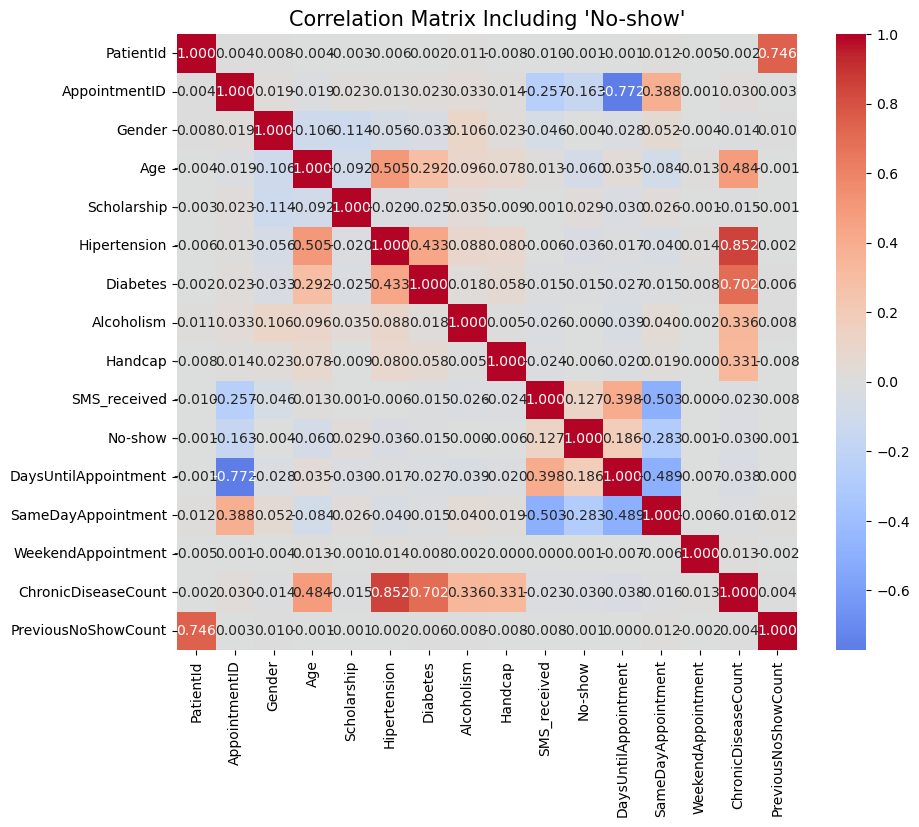

In [24]:


# 2️⃣ Convert 'No-show' column to numeric (No = 0, Yes = 1)
kag_train['No-show'] = kag_train['No-show'].map({'No': 0, 'Yes': 1})

# 4️⃣ Create a correlation matrix INCLUDING the converted No-show column
numeric_df = kag_train.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

# 5️⃣ Print correlation of No-show with all numeric features
print("\n🔹 Correlation with No-show:")
print(corr['No-show'].sort_values(ascending=False))

# 6️⃣ Visual heatmap (No-show will appear here)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix Including 'No-show'", fontsize=15)
plt.show()

<Figure size 800x600 with 0 Axes>

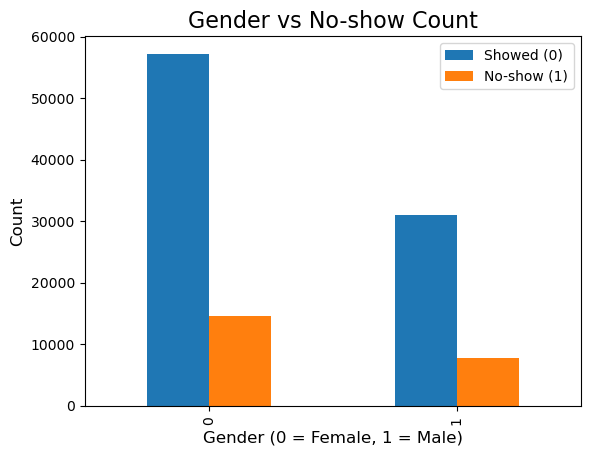

In [25]:
gender_show = pd.crosstab(kag_train['Gender'], kag_train['No-show'])

# Plot bar chart
plt.figure(figsize=(8,6))
gender_show.plot(kind='bar')

plt.title("Gender vs No-show Count", fontsize=16)
plt.xlabel("Gender (0 = Female, 1 = Male)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(["Showed (0)", "No-show (1)"])
plt.show()

In [26]:
# Create a table with counts
age_noshow_counts = kag_train.groupby('AgeGroup')['No-show'].value_counts().unstack().fillna(0)
print(age_noshow_counts)

No-show          0     1
AgeGroup                
Child        15909  4034
Teen          5473  1962
Young Adult  18432  5812
Adult        17375  4489
Middle-aged  18849  3785
Senior       12161  2229


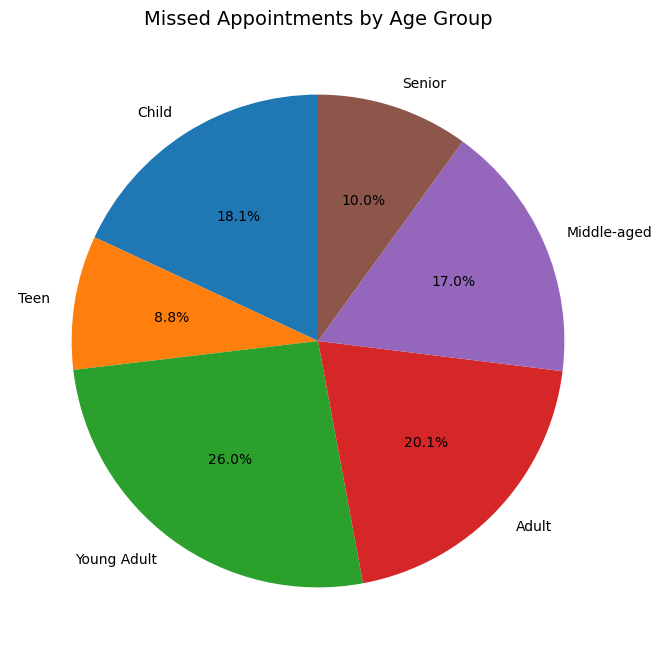

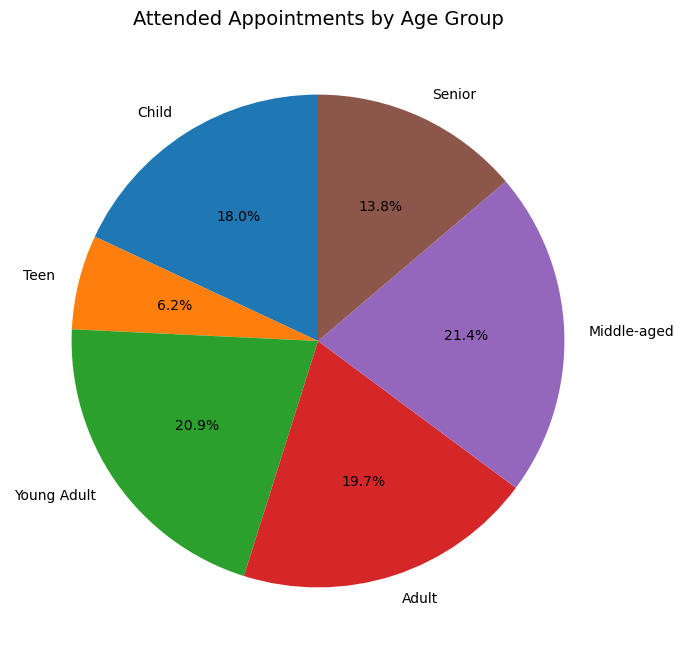

In [27]:


# 5️⃣ Pie chart for Missed (1) appointments
plt.figure(figsize=(8,8))
plt.pie(
    age_noshow_counts[1],           # 1 = Missed
    labels=age_noshow_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Missed Appointments by Age Group", fontsize=14)
plt.show()

# 6️⃣ Pie chart for Showed (0) appointments
plt.figure(figsize=(8,8))
plt.pie(
    age_noshow_counts[0],           # 0 = Showed
    labels=age_noshow_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Attended Appointments by Age Group", fontsize=14)
plt.show()

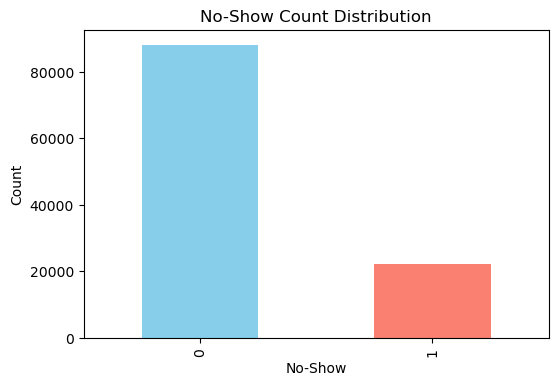

In [28]:
# Count values of Sex
show_counts = kag_train["No-show"].value_counts()

# Check if it's empty before plotting
if not show_counts.empty:
    plt.figure(figsize=(6,4))
    show_counts.plot(kind="bar", color=["skyblue", "salmon"])
    plt.title("No-Show Count Distribution")
    plt.ylabel("Count")
    plt.xlabel("No-Show")
    plt.show()
else:
    print("⚠️ calorie_counts is empty, nothing to plot")

In [29]:
kag_train["NoShowFlag"] = (kag_train["No-show"] == "Yes").astype(int)

# Calculate scale_pos_weight
neg = (kag_train["NoShowFlag"] == 0).sum()
pos = (kag_train["NoShowFlag"] == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: inf


In [30]:
kag_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110522 entries, 100517 to 76224
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   PatientId             110522 non-null  float64 
 1   AppointmentID         110522 non-null  int64   
 2   Gender                110522 non-null  int64   
 3   ScheduledDay          110522 non-null  object  
 4   AppointmentDay        110522 non-null  object  
 5   Age                   110522 non-null  int64   
 6   Neighbourhood         110522 non-null  object  
 7   Scholarship           110522 non-null  int64   
 8   Hipertension          110522 non-null  int64   
 9   Diabetes              110522 non-null  int64   
 10  Alcoholism            110522 non-null  int64   
 11  Handcap               110522 non-null  int64   
 12  SMS_received          110522 non-null  int64   
 13  No-show               110522 non-null  int64   
 14  AppointmentWeekday    110522 non-null

In [38]:
X = kag_train[num_features + cat_features]
y = kag_train['No-show']

In [39]:


# 1️⃣ Define numeric and categorical features
num_features = ['Age', 'DaysUntilAppointment', 'Hipertension','ChronicDiseaseCount','Gender','Diabetes','Alcoholism',
                'Handcap','PreviousNoShowCount','SameDayAppointment']  # numeric
cat_features = ['Neighbourhood', 'AgeGroup', 'ScheduledDay','AppointmentDay','SMS_Status',
                'Scholarship_Status','AppointmentWeekday','IsWeekend']  # categorical

# Keep only columns that exist
num_features = [col for col in num_features if col in kag_train.columns]
cat_features = [col for col in cat_features if col in kag_train.columns]

# 2️⃣ Create transformers
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])
categorical_indices = [X.columns.get_loc(col) for col in cat_features]
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X, y)

# 3️⃣ Create pipeline with XGBoost Classifier
lgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',LGBMClassifier(class_weight = {0: 1, 1: 2},
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42

    ))
])

# 4️⃣ Prepare features and target
X = kag_train[num_features + cat_features]
y = kag_train['No-show']

# 5️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6️⃣ Fit the pipeline
lgb_pipeline.fit(X_train, y_train)
print("✅ Model training completed successfully!")



[LightGBM] [Info] Number of positive: 17851, number of negative: 70566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 883
[LightGBM] [Info] Number of data points in the train set: 88417, number of used features: 202
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.335962 -> initscore=-0.681342
[LightGBM] [Info] Start training from score -0.681342
✅ Model training completed successfully!


Accuracy: 0.7668400814295409

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.86     17642
           1       0.41      0.36      0.38      4463

    accuracy                           0.77     22105
   macro avg       0.63      0.61      0.62     22105
weighted avg       0.76      0.77      0.76     22105



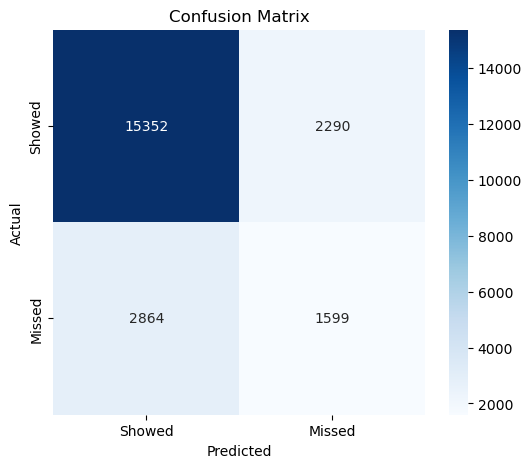

In [40]:
y_pred = lgb_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Showed','Missed'], yticklabels=['Showed','Missed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [44]:
import joblib


# ✅ Save the model to disk
joblib.dump(lgb_pipeline, "noshow_model.pkl")

['noshow_model.pkl']

In [ ]:
REQUIRED_FEATURES

In [48]:
REQUIRED_FEATURES = X_train.columns.tolist()

import joblib
joblib.dump(REQUIRED_FEATURES, "model_features.pkl")
joblib.dump(REQUIRED_FEATURES, "model_features.pkl")

['model_features.pkl']